##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 1

**Group name:** 

**Student names & numbers:**
* [Xue Hu] - [100193]
* [Roos Hogervorst] - [101484]
* [Sas van Damme] - [101990]


---

## 0. Iteration setup

**Import libraries**

In [37]:
# CODE CELL: import the necessary libraries for this iteration

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


**Load dataset(s)**

In [38]:
# CODE CELL: import the necessary dataset(s) for this iteration
df = pd.read_csv('./data/ships_inventory_iter1.csv')


---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**
*Describe the Nebula Brokerage pricing problem. Why is their current "gut feeling" approach a risk?*

Nebula Brokerage is using a pricing strategy based on intuition and rough averages instead of actually analyzing the data. This approach is risky because it is inconsistent and not based on actual market patterns. Because of this approach the company faces two main issues:
1. They are undervaluating some rare ships. This means that these ships are being sold for less than they are worth, which in the end leads to an unnecessary loss of profit.
2. They are also overpricing some ships. Some common ships are being priced too high, which leads to them being left in company storage.


**Business objective(s)**
*Justify why a data-driven baseline is needed*

A data-driven baseline is needed to:
- Provide consistent judgement instead of relying on personal judgement.
- Reduces random pricing decisions.
- Allow the company to measure whether future pricing models are actually improving performance.
- Helps the company understand the overall market


**Data mining goal(s)**
*Explain what type of modeling task this is and why.*

This is a supervised regression task because, the target variable is a continuous numeric value, and because we are trying to predict a price.
However, in this first iteration, we are not building a full predictive model yet. Instead, we are finding the best single constant value to use as a prediciton for all ships.


**Success criteria**
*Determine success criteria for this iteration (the benchmark)*

This iteration will be succesfull if we:
- caluculate the mean and median of Galactic_Credits.
- Decide which value should be used as the baseline prediction.
- Calculate the baseline error.
- Use this error as a benchmark that future pricing models must beat.




---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Include summary statistics and descriptions of data types below. Describe your findings.*

In [39]:
# CODE CELL: Show basic statistics and information
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 368814 entries, 0 to 368813
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Ship_ID            368814 non-null  int64  
 1   Galactic_Credits   368814 non-null  int64  
 2   Model_Cycle        361408 non-null  float64
 3   Ship_Manufacturer  368814 non-null  str    
 4   Sector             368814 non-null  str    
dtypes: float64(1), int64(2), str(2)
memory usage: 14.1 MB


,Ship_ID,Galactic_Credits,Model_Cycle
count,3.688140e+05,368814.000000,361408.000000
mean,7.311485e+09,19453.536818,7511.264529
std,4.381124e+06,15540.472943,9.078571
min,7.301583e+09,501.000000,7400.000000
25%,7.308105e+09,7950.000000,7508.000000
50%,7.312604e+09,15990.000000,7513.000000
75%,7.315245e+09,27990.000000,7517.000000
max,7.317101e+09,777777.000000,7522.000000


Numerical: Galactic_Credits, Model_Cycle

Categorical: Ship_Manufacturer, Sector

**Findings:**
1. Right-Skewed Distribution
The mean price (19,453 credits) is higher than the median price (15,990 credits). This indicates a right-skewed distribution, meaning that a small number of very expensive ships increase the average price.

2. Price Concentration
75% of ships are priced below 27,990 credits, indicating that the majority of ships are concentrated within this price range, while only a small number of ships reach much higher prices.

3. Missing Values: The Model_Cycle column has 361,408 non-null values out of 368,814 total rows. This means there are 7,406 missing that need to be addressed.

4. Potential Outliers: The maximum ship price is 777,777 credits, which is more than 40 times higher than the average price. This indicates the presence of extreme price outliers that may strongly influence statistical measures such as the mean.

**Visualizations and patterns**

*Discover patterns in the data by creating visualizations. Create at least a histogram of Galactic_Credits. Describe your observations.*

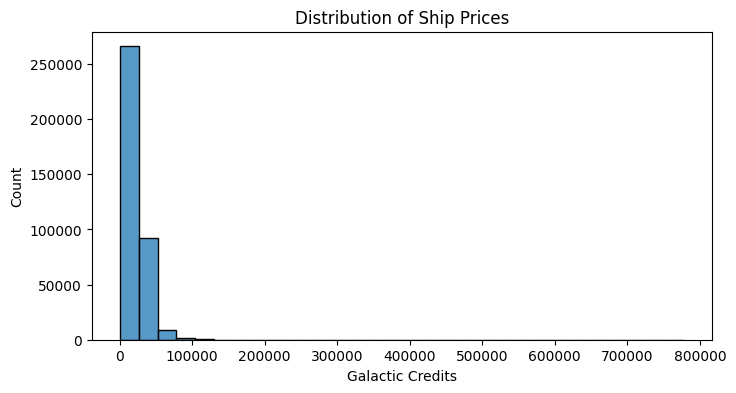

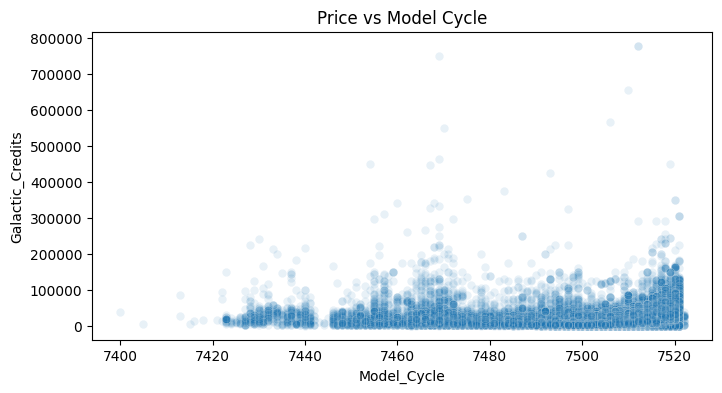

In [40]:
# CODE CELL: Generate visualizations (e.g., scatter plots, histograms)
# histogram
plt.figure(figsize=(8,4))
sns.histplot(df['Galactic_Credits'], bins=30)
plt.title("Distribution of Ship Prices")
plt.xlabel("Galactic Credits")
plt.ylabel("Count")
plt.show()

# scatter plot
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='Model_Cycle', y='Galactic_Credits', alpha=0.1)
plt.title('Price vs Model Cycle')
plt.show()


In [41]:
df.duplicated().sum()

np.int64(500)

**Data insights and data quality**
* **Insights:** What are the key trends? What does the distribution look like? What does that mean? 
* **Quality issues:** Document missing values, duplicates, outliers, etc.

Observations: 
1. Price Distribution

    The histogram shows a strongly right-skewed distribution. Most ships are priced below 30,000 Galactic Credits, while a small number of ships reach extremely high prices (up to 777,777 credits). These extreme values pull the mean price above the median.

2. Model Cycle vs Price

    The scatter plot shows that most ships were produced in recent model cycles. However, ship prices vary widely within each cycle and no clear linear relationship between model cycle and price is visible. This suggests that model cycle alone may not strongly determine ship price.

3. Missing Values

    The column Model_Cycle contains missing values. Out of 368,814 records, 7,406 entries do not have a model cycle value. These missing values will need to be addressed during data preparation.

4. Potential Outliers

    The maximum ship price is 777,777 credits, which is more than 40 times higher than the average price. This indicates the presence of extreme price outliers that may strongly influence statistical measures such as the mean.

5. Duplicates

    500 duplicate rows were detected in the dataset. These rows contain identical values across all columns, including the ship identifier. Since identical records do not add additional information, they will be removed during the data preparation phase to avoid potential bias in the analysis.

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify steps taken (e.g., imputation, handling outliers, fixing other errors).*

In [42]:
# CODE CELL: Data cleaning and preprocessing steps
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()
df_clean = df_clean.dropna(subset=['Model_Cycle'])
price_cap = df_clean['Galactic_Credits'].quantile(0.99)
df_clean = df_clean[df_clean['Galactic_Credits'] <= price_cap]
df_clean.info()
df_clean.describe()

<class 'pandas.DataFrame'>
Index: 357317 entries, 0 to 368813
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Ship_ID            357317 non-null  int64  
 1   Galactic_Credits   357317 non-null  int64  
 2   Model_Cycle        357317 non-null  float64
 3   Ship_Manufacturer  357317 non-null  str    
 4   Sector             357317 non-null  str    
dtypes: float64(1), int64(2), str(2)
memory usage: 16.4 MB


,Ship_ID,Galactic_Credits,Model_Cycle
count,3.573170e+05,357317.000000,357317.000000
mean,7.311480e+09,18743.945443,7511.259691
std,4.382038e+06,13284.949858,8.951267
min,7.301583e+09,501.000000,7400.000000
25%,7.308095e+09,7900.000000,7508.000000
50%,7.312591e+09,15900.000000,7513.000000
75%,7.315242e+09,27590.000000,7517.000000
max,7.317101e+09,68788.000000,7522.000000


Cleaning and preprocessing steps:
1. Duplicate remove
A total of 500 duplicate rows were detected. Since each ship has a unique Ship_ID, identical rows represent repeated records of the same ship. These duplicates were removed to ensure that each ship appears only once in the dataset.

2. Handling Missing Values
Missing values represent only a small proportion of the dataset (~2%), removing these rows has minimal impact on the dataset while avoiding the introduction of artificial values.

3. Handling Outliers
Prices above the 99th percentile were removed to limit the influence of extreme outliers while preserving the vast majority of the observations.


**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [43]:
# OPTIONAL CODE CELL: Additional preprocessing steps

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Describe and justify the creation of your simple benchmark model to predict Galactic_Credits*

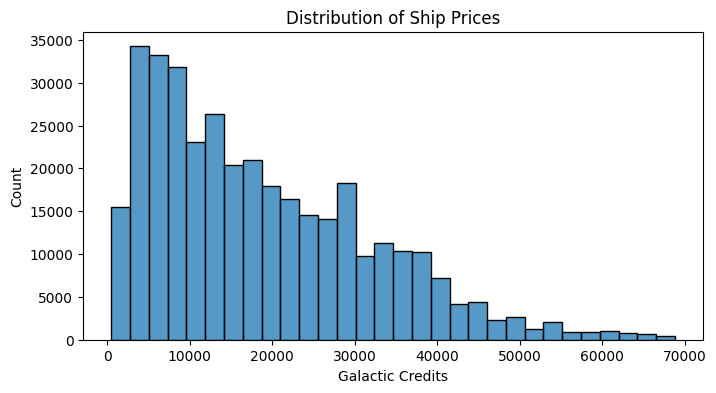

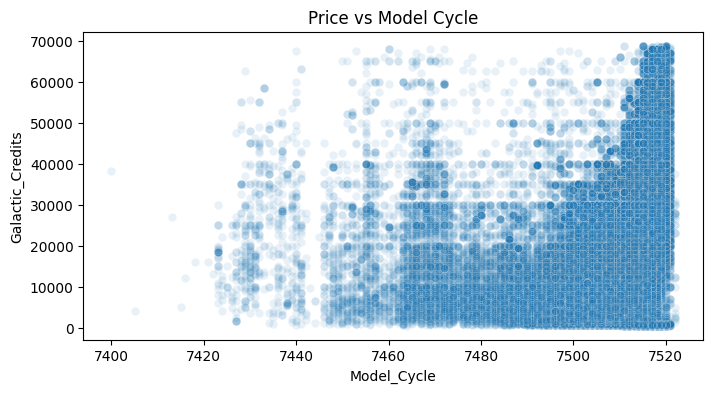

In [44]:
# CODE CELL: Model training and setup code

y_true = df_clean['Galactic_Credits']

plt.figure(figsize=(8,4))
sns.histplot(df_clean['Galactic_Credits'], bins=30)
plt.title("Distribution of Ship Prices")
plt.xlabel("Galactic Credits")
plt.ylabel("Count")
plt.show()

# scatter plot
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df_clean, x='Model_Cycle', y='Galactic_Credits', alpha=0.1)
plt.title('Price vs Model Cycle')
plt.show()

baseline_mean = y_true.mean()
baseline_median = y_true.median()

y_pred_mean = np.full(len(y_true), baseline_mean)
y_pred_median = np.full(len(y_true), baseline_median)



I made a simple baseline by predicting the same price for every ship. I tried two options: the mean and the median of Galactic_Credits.
* Mean is best if we care about squared errors. (RMSE)
* Median is best if we care about absolute errors. (MAE)

This gives a basic benchmark to see if future models actually improve over just guessing a single number.

**Testing and performance**
*Describe how you tested the model and interpret the metrics. Make sure to present the metrics in a clear overview.*

In [45]:
# CODE CELL: Model evaluation code
mae_mean = mean_absolute_error(y_true, y_pred_mean)
rmse_mean = np.sqrt(mean_squared_error(y_true, y_pred_mean))

mae_median = mean_absolute_error(y_true, y_pred_median)
rmse_median = np.sqrt(mean_squared_error(y_true, y_pred_median))

performance_results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Mean Strategy': [mae_mean, rmse_mean],
    'Median Strategy': [mae_median, rmse_median]
})
display(performance_results)

df_clean.to_csv("ships_inventory_clean.csv", index=False)





,Metric,Mean Strategy,Median Strategy
0,MAE,10893.034496,10652.056963
1,RMSE,13284.931268,13585.927443


The median strategy results in a slightly lower MAE, meaning it predicts the typical ship price more accurately. The mean strategy results in a lower RMSE, because the mean minimizes squared errors. Since the price distribution is right-skewed, the median provides a slightly more robust baseline prediction.

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*What is the difference between the metrics? What does this mean? Did you meet the goals set in the Business Understanding?*



**Key findings and limitations**
*What did you learn? What are the limitations of this current model?*


**Metric Comparison:** The Median Strategy (10,652) results in a slightly lower MAE than the Mean Strategy (10,893) by about 241 credits. While the Mean model minimizes squared errors (RMSE), the Median model performs slightly better at minimizing the absolute difference from the actual ship prices.

**Business Meaning:** This means that if Nebula Brokerage used the Median as a simple pricing benchmark, the predicted price would still be on average about 10,652 credits away from the actual market price. Considering that many ships are priced around 15,000–20,000 credits, this indicates that the baseline model still produces large prediction errors.

**Key Findings:** The dataset shows a right-skewed price distribution, where a small number of high-price ships increase the average price. Because of this, the median provides a slightly more robust baseline prediction than the mean.

**Limitation:**
1. Feature neglect:
The current baseline model does not use any ship features such as Model_Cycle, Ship_Manufacturer, or Sector.
2. Limited predictive power:
The high MAE shows that predicting a single constant price for every ship is too simplistic and cannot capture differences between ships.

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Xue | *Through visualizations like histograms and scatter plots, I identified that the price distribution is heavily right-skewed* | *I learned that raw numbers can be misleading without visualization, as histograms immediately revealed a right-skewed distribution that summary statistics alone might hide.* |
| Sas | *To ensure model reliability, I cleaned data by removing rows and filtered outliers* | *I realized that in datasets, removing records with missing values is often safer than guessing data, as it maintains the integrity of the final model.* |
| Roos | *I defined the business problem, objectives, and success criteria, and helped interpret the baseline model results.* | *I learned that clearly defining the problem and benchmark is important to evaluate whether a model truly improves business performance.* |